# Procesamiento y ajuste de distribuciones — Dataset Gimnasio

El objetivo de este trabajo consiste en:

1.  Realizar el procesamiento de un set de datos de un gimnasio mediante el uso del lenguaje de programación Python y las bibliotecas Pandas y Numpy.
2.  Obtener información necesaria del dataset con Pandas y desarrollar visualizaciones básicas de los datos mediante la librería Matplotlib.
3.  Generar manualmente una columna de **tiempo entre llegadas** a partir de las columnas `dia` y `hora_llegada`, y compararla con la columna `tiempo_entre_llegadas_min` ya existente en el dataset.
4.  Ajustar los datos de origen a una serie de funciones de densidad de probabilidad sugeridas, mediante el uso de la biblioteca Fitter.
5.  Con la obtención de la(s) fdp(s) sugeridas, simular un array de datos y verificar por medio de gráficos o un nuevo ajuste, que los datos generados son de características similares a los de origen.

## 1. Importación de bibliotecas

En este primer paso importamos todas las bibliotecas necesarias para realizar nuestro procesamiento de datos.
- `numpy` y `pandas` para el manejo de datos.
- `matplotlib` para gráficos.
- `scipy.stats` para herramientas estadísticas y generación de variables aleatorias.
- `fitter` para el ajuste automático de distribuciones.

Generalmente es buena práctica utilizar alias para los nombres de estas bibliotecas (`np`, `pd` y `plt`) cuando se las importa.

In [1]:
# Instalación de fitter (ejecutar solo si no está instalado)
# !pip install fitter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 2. Carga de datos

Nuestro dataset es un archivo CSV local ubicado en la carpeta `data/`. Utilizaremos la función `read_csv` de Pandas para cargarlo.

Los datos leídos los cargamos en una variable llamada `df_gimnasio`.

In [3]:
# Carga del dataset local
df_gimnasio = pd.read_csv('../data/dataset_gimnasio_1000.csv')

In [4]:
# Verificamos el tipo del objeto cargado
type(df_gimnasio)

pandas.DataFrame

## 3. Análisis Exploratorio de Datos (EDA)

A continuación inspeccionamos la estructura, tipos de datos, valores nulos y primeras filas del dataset para comprender su contenido.

In [5]:
# Dimensiones del DataFrame: (filas, columnas)
df_gimnasio.shape

(1000, 6)

In [6]:
# Primeras filas del dataset
df_gimnasio.head(10)

,id_socio,dia,hora_llegada,tiempo_entre_llegadas_min,tipo_usuario,tiempo_uso_maquina_min
0,1,Lunes,19:05:52,8.256,Cardio,42.417
1,2,Martes,19:16:06,3.131,Funcional,51.836
2,3,Martes,20:57:46,3.640,Musculacion,39.400
3,4,Martes,18:29:57,5.165,Musculacion,41.349
4,5,Martes,18:10:16,8.640,Musculacion,62.410
5,6,Lunes,19:56:41,1.684,Funcional,25.976
6,7,Viernes,18:09:37,1.148,Cardio,33.503
7,8,Jueves,20:25:04,1.205,Cardio,37.738
8,9,Miercoles,20:18:18,0.212,Cardio,35.338
9,10,Sabado,09:35:10,2.656,Musculacion,71.268


In [7]:
# Tipos de datos de cada columna
df_gimnasio.dtypes

id_socio                       int64
dia                              str
hora_llegada                     str
tiempo_entre_llegadas_min    float64
tipo_usuario                     str
tiempo_uso_maquina_min       float64
dtype: object

In [8]:
# Verificación de valores nulos por columna
df_gimnasio.isnull().sum()

id_socio                     0
dia                          0
hora_llegada                 0
tiempo_entre_llegadas_min    0
tipo_usuario                 0
tiempo_uso_maquina_min       0
dtype: int64

In [9]:
# Estadísticas descriptivas de las columnas numéricas
df_gimnasio.describe()

,id_socio,tiempo_entre_llegadas_min,tiempo_uso_maquina_min
count,1000.000000,1000.000000,1000.000000
mean,500.500000,3.583455,42.266876
std,288.819436,3.957000,15.254927
min,1.000000,0.010000,9.444000
25%,250.750000,0.946250,30.848750
50%,500.500000,2.057000,40.050500
75%,750.250000,5.169000,54.172500
max,1000.000000,31.060000,84.446000


## 4. Generación manual de la columna de Tiempo Entre Llegadas

El dataset ya contiene una columna `tiempo_entre_llegadas_min`. Sin embargo, vamos a generar una columna adicional calculándola manualmente a partir de las columnas `dia` y `hora_llegada`.

**Lógica:** El tiempo entre llegadas es la diferencia en minutos entre la llegada del socio actual y la del socio anterior. Es fundamental considerar **tanto el día como la hora**, ya que si solo ordenamos por hora, las llegadas de distintos días se mezclarían incorrectamente.

Para ello:
1. Mapeamos la columna `dia` a un valor numérico de orden (Lunes=0, Martes=1, ..., Sábado=5).
2. Convertimos la columna `hora_llegada` a `timedelta`.
3. Creamos un **timestamp combinado** sumando el offset del día (en días) con la hora de llegada. Esto produce un valor único y ordenable que respeta la secuencia cronológica real.
4. Ordenamos el DataFrame por este timestamp combinado.
5. Calculamos la diferencia (`diff()`) entre filas consecutivas.
6. Convertimos el resultado a minutos decimales.

In [10]:
# Paso 1: Mapeamos los días de la semana a un orden numérico
orden_dias = {
    'Lunes': 0,
    'Martes': 1,
    'Miercoles': 2,
    'Jueves': 3,
    'Viernes': 4,
    'Sabado': 5
}
df_gimnasio['dia_num'] = df_gimnasio['dia'].map(orden_dias)
print('Días mapeados correctamente:')
print(df_gimnasio[['dia', 'dia_num']].drop_duplicates().sort_values('dia_num'))

Días mapeados correctamente:
         dia  dia_num
0      Lunes        0
1     Martes        1
8  Miercoles        2
7     Jueves        3
6    Viernes        4
9     Sabado        5


In [11]:
# Paso 2: Convertimos 'hora_llegada' (formato HH:MM:SS) a timedelta
df_gimnasio['hora_llegada_td'] = pd.to_timedelta(df_gimnasio['hora_llegada'])

In [12]:
# Paso 3: Creamos un timestamp combinado (día + hora) como timedelta total
df_gimnasio['timestamp_combinado'] = (
    pd.to_timedelta(df_gimnasio['dia_num'], unit='D') + df_gimnasio['hora_llegada_td']
)

In [13]:
# Paso 4: Ordenamos el DataFrame por el timestamp combinado
df_gimnasio_ordenado = df_gimnasio.sort_values(by='timestamp_combinado').reset_index(drop=True)

In [14]:
# Paso 5: Calculamos la diferencia entre llegadas consecutivas
df_gimnasio_ordenado['delta_llegada'] = df_gimnasio_ordenado['timestamp_combinado'].diff()

In [15]:
# Paso 6: Convertimos el timedelta resultante a minutos decimales
df_gimnasio_ordenado['tiempo_entre_llegadas_calculado_min'] = (
    df_gimnasio_ordenado['delta_llegada'].dt.total_seconds() / 60.0
)

In [16]:
# Verificamos el resultado
df_gimnasio_ordenado[['id_socio', 'dia', 'hora_llegada', 'tiempo_entre_llegadas_min', 'tiempo_entre_llegadas_calculado_min']].head(20)

,id_socio,dia,hora_llegada,tiempo_entre_llegadas_min,tiempo_entre_llegadas_calculado_min
0,586,Lunes,18:01:46,1.780,NaN
1,399,Lunes,18:02:25,0.653,0.650000
2,954,Lunes,18:02:25,0.684,0.000000
3,171,Lunes,18:02:25,0.606,0.000000
4,868,Lunes,18:02:25,0.721,0.000000
5,842,Lunes,18:02:25,0.607,0.000000
6,332,Lunes,18:02:39,0.230,0.233333
7,866,Lunes,18:02:39,0.264,0.000000
8,223,Lunes,18:02:39,0.226,0.000000
9,455,Lunes,18:02:44,0.021,0.083333


**Nota:** La primera fila tendrá un valor `NaN` en la columna calculada. Eliminamos ese registro antes de continuar.

In [17]:
# Eliminamos el primer registro con NaN en la columna calculada
df_gimnasio_limpio = df_gimnasio_ordenado.dropna(subset=['tiempo_entre_llegadas_calculado_min']).copy()
print(f'Registros después de eliminar NaN: {len(df_gimnasio_limpio)}')

Registros después de eliminar NaN: 999


### 4.1 Filtrado de tiempos entre llegadas no representativos

Al calcular el `diff()` sobre el `timestamp_combinado`, las **transiciones entre días** generan deltas muy grandes que no son representativos del comportamiento de llegadas *durante la jornada*.

**Criterio:** Descartamos todos los tiempos entre llegadas **mayores a 120 minutos (2 horas)**, ya que corresponden a transiciones entre jornadas y no a intervalos reales entre socios.

In [18]:
# Filtramos valores no representativos: descartamos deltas > 120 minutos (2 horas)
UMBRAL_MAX_MINUTOS = 120

registros_antes = len(df_gimnasio_limpio)
df_gimnasio_limpio = df_gimnasio_limpio[
    df_gimnasio_limpio['tiempo_entre_llegadas_calculado_min'] <= UMBRAL_MAX_MINUTOS
].copy()
registros_despues = len(df_gimnasio_limpio)

print(f'Registros antes del filtro:   {registros_antes}')
print(f'Registros después del filtro: {registros_despues}')
print(f'Registros descartados:        {registros_antes - registros_despues}')

Registros antes del filtro:   999
Registros después del filtro: 994
Registros descartados:        5


## 5. Extracción de la variable objetivo

Extraemos la columna calculada manualmente como un array de NumPy. Esta será la variable sobre la cual realizaremos el análisis de distribuciones.

In [19]:
datos_tel = df_gimnasio_limpio['tiempo_entre_llegadas_calculado_min'].values
print(f'Tipo de dato: {type(datos_tel)}')
print(f'Cantidad de observaciones: {len(datos_tel)}')

Tipo de dato: <class 'numpy.ndarray'>
Cantidad de observaciones: 994


## 6. Visualización — Histograma del Tiempo Entre Llegadas

Generamos un histograma para observar la forma empírica de la distribución del tiempo entre llegadas calculado.

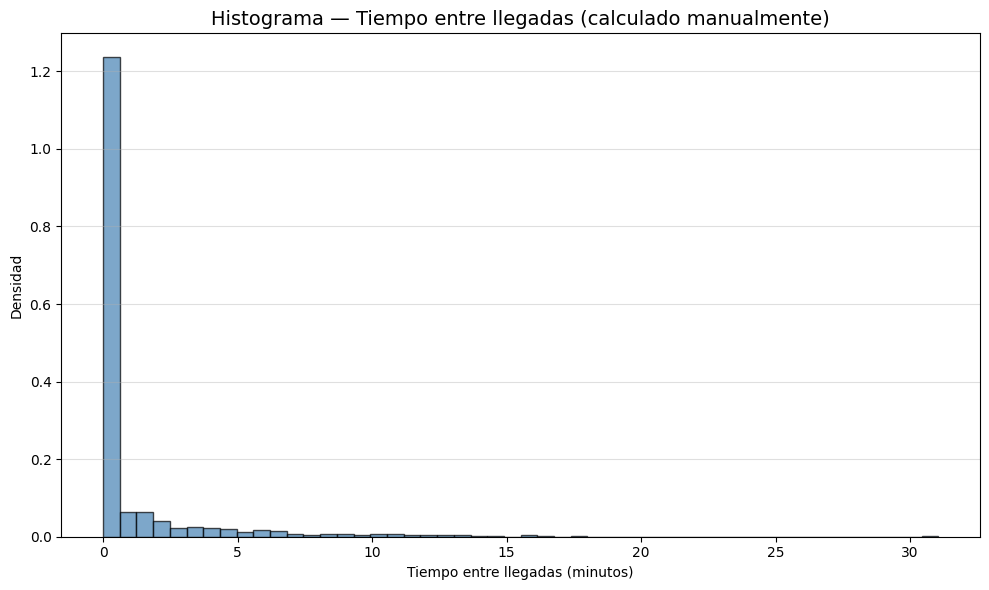

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(datos_tel, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
plt.title('Histograma — Tiempo entre llegadas (calculado manualmente)', fontsize=14)
plt.xlabel('Tiempo entre llegadas (minutos)')
plt.ylabel('Densidad')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Ajuste probabilístico con Fitter

Utilizamos la librería `Fitter` para evaluar múltiples distribuciones de `scipy.stats` y encontrar la que mejor se ajusta a nuestros datos empíricos.

In [21]:
from fitter import Fitter

In [22]:
# Inicializamos Fitter con los datos y un subconjunto de distribuciones candidatas
f = Fitter(
    datos_tel,
    distributions=['expon', 'gamma', 'lognorm', 'norm', 'weibull_min', 'beta', 'uniform', 'rayleigh']
)
f.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
beta,2.457282,-53969.577559,-53949.970610,0.329512,0.709234,0.000000e+00
weibull_min,2.945141,-56812.602832,-56797.897621,1.731363,0.709256,0.000000e+00
expon,2.970973,2087.819896,2097.623370,0.872678,0.709256,0.000000e+00
gamma,3.083518,-55298.835228,-55284.130016,1.199516,0.709256,0.000000e+00
rayleigh,4.914425,4318.317208,4328.120683,1.231027,0.448750,3.852650e-183


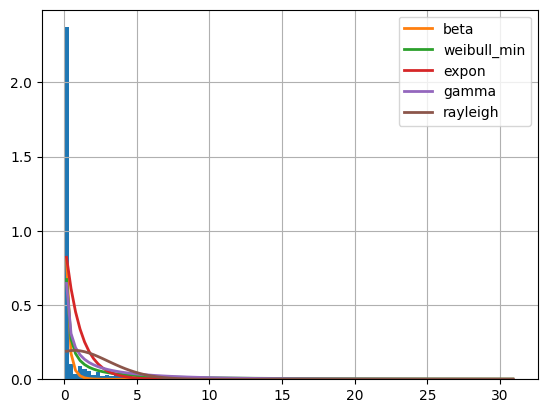

In [23]:
# Resumen de las mejores distribuciones (top 5)
f.summary(5)

In [24]:
# Obtenemos la mejor distribución sobre los datos ORIGINALES
mejor_original = f.get_best(method='sumsquare_error')

dist_original = list(mejor_original.keys())[0]
params_original = mejor_original[dist_original]

print('=== Mejor distribución (datos originales) ===')
print(f'  Distribución: {dist_original}')
print(f'  Parámetros  : {params_original}')

=== Mejor distribución (datos originales) ===
  Distribución: beta
  Parámetros  : {'a': np.float64(0.2013069239322875), 'b': np.float64(264.93161390805676), 'loc': np.float64(-1.7893876865491145e-24), 'scale': np.float64(124.0119547630656)}


## 8. Verificación y Simulación

Con los parámetros devueltos por `get_best()`, usamos `scipy.stats` para generar un array de datos sintéticos simulados y los contrastamos visualmente con el histograma original.

In [25]:
# Obtenemos la función de distribución de scipy.stats dinámicamente
dist_scipy = getattr(stats, dist_original)

# Generamos datos simulados con los parámetros obtenidos
datos_simulados = dist_scipy.rvs(**params_original, size=len(datos_tel), random_state=42)
print(f'Datos simulados generados: {len(datos_simulados)}')

Datos simulados generados: 994


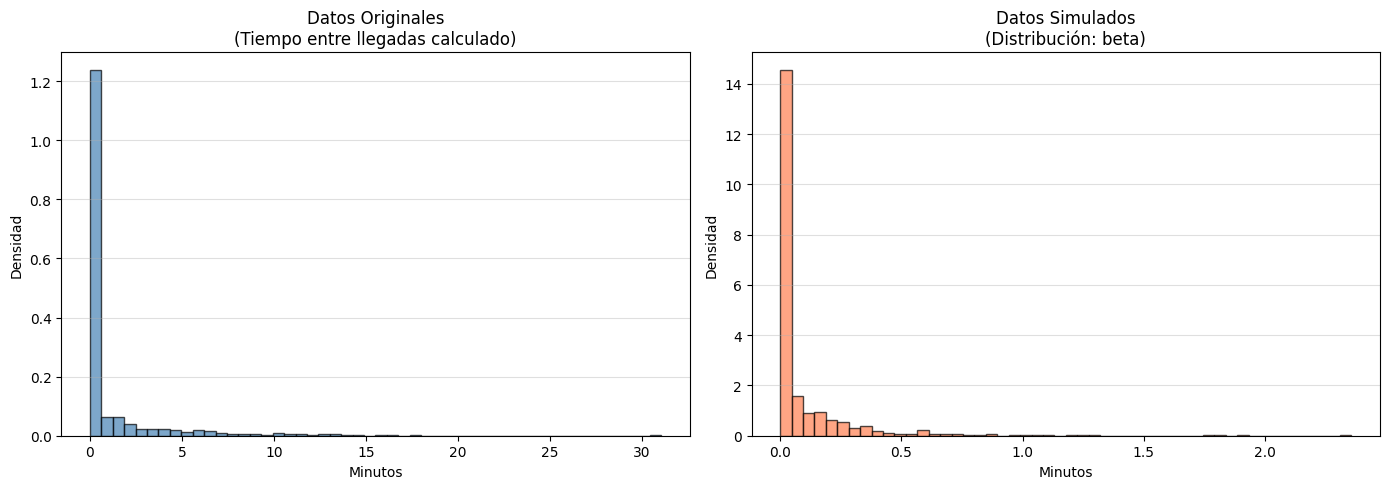

In [26]:
# Visualización comparativa: datos originales vs datos simulados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(datos_tel, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Datos Originales\n(Tiempo entre llegadas calculado)', fontsize=12)
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.4)

axes[1].hist(datos_simulados, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title(f'Datos Simulados\n(Distribución: {dist_original})', fontsize=12)
axes[1].set_xlabel('Minutos')
axes[1].set_ylabel('Densidad')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 8.1 Re-ajuste sobre datos simulados (Verificación)

Si el análisis fue correcto, al aplicar Fitter sobre los datos simulados debería sugerir la misma distribución obtenida originalmente.

In [27]:
v = Fitter(
    datos_simulados,
    distributions=['expon', 'gamma', 'lognorm', 'norm', 'weibull_min', 'uniform']
)
v.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
expon,300.812070,-2679.625652,-2669.822178,0.447427,0.420553,7.238835e-160
weibull_min,321.104182,-6137.876815,-6123.171603,2.229194,0.190364,5.106698e-32
gamma,331.154393,-6034.757774,-6020.052563,2.490350,0.249037,8.516981e-55
lognorm,354.414349,-5724.299006,-5709.593794,2.104928,0.231974,1.626841e-47
norm,565.924548,-189.881651,-180.078177,0.948580,0.331945,4.101131e-98


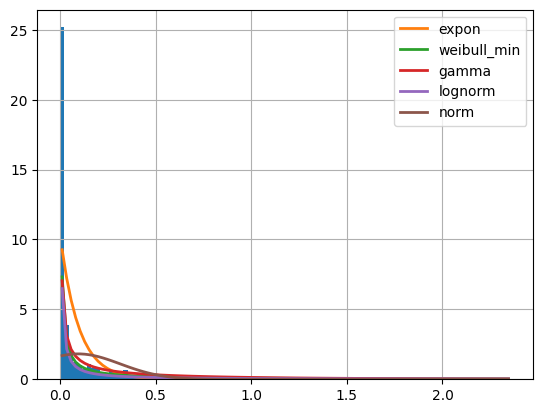

In [28]:
v.summary(5)

In [29]:
# Obtenemos la mejor distribución sobre los datos SIMULADOS
mejor_verificacion = v.get_best(method='sumsquare_error')

dist_verificacion = list(mejor_verificacion.keys())[0]
params_verificacion = mejor_verificacion[dist_verificacion]

print('=== Mejor distribución (datos simulados — verificación) ===')
print(f'  Distribución: {dist_verificacion}')
print(f'  Parámetros  : {params_verificacion}')

=== Mejor distribución (datos simulados — verificación) ===
  Distribución: expon
  Parámetros  : {'loc': -1.638727054926455e-24, 'scale': 0.09537752647600757}


---

## 9. Declaración de parámetros para Simulación

Esta sección consolida los resultados del análisis y declara las variables finales que serán utilizadas en una simulación posterior.

Se presentan **tres conjuntos de valores**:
1. **Fitter (datos originales)**: la distribución que mejor ajusta a los datos reales del gimnasio.
2. **Verificación (datos simulados)**: la distribución que Fitter propone al re-ajustar sobre los datos generados sintéticamente. Si coincide con la original, confirma la validez del ajuste.
3. **Parámetros elegidos para la simulación**: los valores finales que el equipo decide usar. Por defecto se inicializan con los de Fitter (datos originales), pero pueden ser editados manualmente.

In [30]:
# =============================================================
# PARÁMETROS ELEGIDOS PARA LA SIMULACIÓN
# Completar / ajustar estos valores según el criterio del equipo.
# Por defecto se inicializan con los valores de Fitter (datos originales).
# =============================================================

# --- Tiempo entre llegadas (TEL) ---
TEL_distribucion  = dist_original             # Nombre de la distribución elegida
TEL_params        = params_original.copy()    # Parámetros elegidos

# Ejemplo de sobrescritura manual (descomentar y editar si se elige una distribución distinta):
# TEL_distribucion = 'expon'
# TEL_params       = {'loc': 0.0, 'scale': 5.2}

In [31]:
# =============================================================
# RESUMEN FINAL — Tabla comparativa
# =============================================================

print('=' * 60)
print('RESUMEN DE DISTRIBUCIONES — Tiempo Entre Llegadas (min)')
print('=' * 60)
print(f'  Observaciones usadas : {len(datos_tel)}')
print(f'  Umbral de filtrado   : {UMBRAL_MAX_MINUTOS} min')
print()
print('--- 1. Distribución hallada sobre datos ORIGINALES ---')
print(f'  Distribución : {dist_original}')
for k, val in params_original.items():
    print(f'  {k:<12} : {val:.6f}')
print()
print('--- 2. Distribución optada por Fitter sobre datos SIMULADOS (verificación) ---')
print(f'  Distribución : {dist_verificacion}')
for k, val in params_verificacion.items():
    print(f'  {k:<12} : {val:.6f}')
lambda_val = 1 / params_verificacion['scale']
print(f'  lambda (1/scale) : {lambda_val:.6f}')
print()
print('--- 3. Parámetros ELEGIDOS para la simulación ---')
print(f'  Distribución : {TEL_distribucion}')
for k, val in TEL_params.items():
    print(f'  {k:<12} : {val:.6f}')
print('=' * 60)

RESUMEN DE DISTRIBUCIONES — Tiempo Entre Llegadas (min)
  Observaciones usadas : 994
  Umbral de filtrado   : 120 min

--- 1. Distribución hallada sobre datos ORIGINALES ---
  Distribución : beta
  a            : 0.201307
  b            : 264.931614
  loc          : -0.000000
  scale        : 124.011955

--- 2. Distribución optada por Fitter sobre datos SIMULADOS (verificación) ---
  Distribución : expon
  loc          : -0.000000
  scale        : 0.095378
  lambda (1/scale) : 10.484650

--- 3. Parámetros ELEGIDOS para la simulación ---
  Distribución : beta
  a            : 0.201307
  b            : 264.931614
  loc          : -0.000000
  scale        : 124.011955
